# Dataset Preparation

- Create atoms objects for guess structures
- output: pd.series of ase objects pr pymatgen objects
- calculate garget property for learning set: formation energies


In [1]:
from Tools.DatasetTools.Commoms import *
from dependencies.bopfoxfeaturizer.BopFoxFeaturizer.Featurizer import Featurizer
from Tools.DatasetTools.Tools import need_to_update
from Tools.DatasetTools.SublatticeSorter import *
from pymatgen.io.ase import AseAtomsAdaptor
from mendeleev import element

In [2]:
from mp_api.client import MPRester

# options 

In [3]:
dataset = 'Fe-Mo'  # 'Cr-Co-W' 'Fe-Mo'
cases = ['POSCAR.initial', 'POSCAR.relaxed-all']
rescale_by_atoms = True #  False]
subcases = ['rescaled',  'noscaled' ] 
Force = True
CuratedBS = os.path.join(dataset,'CuratedParsedBriefSummary.pkl')

In [4]:
MP_keys = {'Fe' : 'mp-13', 'Mo' : 'mp-129'}

In [5]:
BS = pd.read_pickle(CuratedBS)

In [6]:
bcc_bs = BS.loc[BS.index.str.contains('Fe.*bcc.*FM', regex=True)]

In [7]:
bcc_bs

,,V,E0,B,fit,xc,encut,deltak,ncrash,nelem,...,V0,atom_A,atom_B,num_atom_A,num_atom_B,num_atoms,Fe_pv,Mo_sv,Mag,Phase
Fe_pv1.bcc.FM,bulk bcc.FM,11.352006 A,-8.255228,170.727430 GPa,murnaghan volume_relaxed,PBE-PAW,440,0.016,0,1,...,11.356868,Fe_pv,,1,0,1,1.0,0.0,FM,bcc
Fe_pv2.bcc-cubic.FM,bulk bcc-cubic.FM,11.367016 A,-8.254731,187.308419 GPa,murnaghan volume_relaxed,PBE-PAW,440,0.015,0,1,...,11.375458,Fe_pv,,2,0,2,1.0,0.0,FM,bcc


In [8]:
Features = Featurizer(BS)

In [9]:
BS.dropna().describe()

,E0,nelem,B0,V0,num_atom_A,num_atom_B,num_atoms,Fe_pv,Mo_sv
count,292.000000,292.000000,292.000000,292.000000,292.00000,292.000000,292.000000,292.000000,292.000000
mean,-9.347206,1.845890,235.138358,13.582107,12.89726,10.291096,23.188356,0.498634,0.501366
std,0.746336,0.361674,31.685307,1.654945,10.85723,9.537817,13.755429,0.292605,0.292605
min,-10.932821,1.000000,141.243922,10.193528,1.00000,0.000000,1.000000,0.000000,0.000000
25%,-9.955671,2.000000,217.823336,12.275667,4.00000,2.750000,13.000000,0.262500,0.266667
50%,-9.332258,2.000000,240.028922,13.425116,10.00000,8.500000,24.000000,0.500000,0.500000
75%,-8.825165,2.000000,260.406947,14.978348,18.00000,16.000000,30.000000,0.733333,0.737500
max,-7.780036,2.000000,287.828951,16.550514,53.00000,52.000000,53.000000,1.000000,1.000000


## Prepare targets 

One target still missing is formation Energy. Some Convenience functions to do this has been set

In [10]:
if 'Fe' in dataset:
    ground_states= Features.get_ground_states_energies(force_mag_phase=('Fe_pv', 'NM', 'fcc'))
else:
    ground_states = Features.get_ground_states_energies()

In [11]:
ground_states

{('Fe_pv1', 'bcc', 'FM'): -8.255227964543023,
 ('Fe_pv2', 'hcp', 'NM'): -8.18407186323532,
 ('Fe_pv4', 'fcc', 'NM'): -8.105011456799609,
 ('Mo_sv1', 'bcc', 'FM'): -10.932754996062988,
 ('Mo_sv1', 'bcc', 'NM'): -10.932821158319513}

As seen, at this point ground states are badly determined. They will be calculated after sanitation of dft data

In [12]:
this_ground_states = {}
if 'Fe' in dataset:
    print('correcting for Fe')
    this_ground_states[('Fe_pv', 'FM')] = ground_states[('Fe_pv1', 'bcc', 'FM')]
    this_ground_states[('Fe_pv', 'NM')] = ground_states[('Fe_pv2', 'hcp', 'NM')]
if 'Mo' in dataset:                                                     
    this_ground_states[('Mo_sv', 'FM')] = ground_states[('Mo_sv1', 'bcc', 'FM')]
    this_ground_states[('Mo_sv', 'NM')] = ground_states[('Mo_sv1', 'bcc', 'NM')]

correcting for Fe


In [13]:
this_other_ground_states = {}
if 'Fe' in dataset:
    print('correcting for Fe')
    this_other_ground_states[('Fe_pv', 'FM')] = ground_states[('Fe_pv1', 'bcc', 'FM')]
    this_other_ground_states[('Fe_pv', 'NM')] = ground_states[('Fe_pv4', 'fcc', 'NM')]
if 'Mo' in dataset:                                                            
    this_other_ground_states[('Mo_sv', 'FM')] = ground_states[('Mo_sv1', 'bcc', 'FM')]
    this_other_ground_states[('Mo_sv', 'NM')] = ground_states[('Mo_sv1', 'bcc', 'NM')]

correcting for Fe


In [14]:
BS['EF_fmbcc'] = Features.get_formation_energies(this_ground_states, force_reference_energy={'Fe_pv': ground_states[('Fe_pv1', 'bcc', 'FM')]})

In [15]:
BS['EF_nmhcp'] =  Features.get_formation_energies(this_ground_states)

In [16]:
BS['EF_nmfcc'] =  Features.get_formation_energies(this_other_ground_states)

In [17]:
BS.describe()

,E0,nelem,B0,V0,num_atom_A,num_atom_B,num_atoms,Fe_pv,Mo_sv,EF_fmbcc,EF_nmhcp,EF_nmfcc
count,292.000000,292.000000,292.000000,292.000000,292.00000,292.000000,292.000000,292.000000,292.000000,292.000000,292.000000,292.000000
mean,-9.347206,1.845890,235.138358,13.582107,12.89726,10.291096,23.188356,0.498634,0.501366,0.250462,0.229052,0.205263
std,0.746336,0.361674,31.685307,1.654945,10.85723,9.537817,13.755429,0.292605,0.292605,0.161952,0.162156,0.166363
min,-10.932821,1.000000,141.243922,10.193528,1.00000,0.000000,1.000000,0.000000,0.000000,-0.015446,-0.042841,-0.085488
25%,-9.955671,2.000000,217.823336,12.275667,4.00000,2.750000,13.000000,0.262500,0.266667,0.124923,0.102939,0.072821
50%,-9.332258,2.000000,240.028922,13.425116,10.00000,8.500000,24.000000,0.500000,0.500000,0.228259,0.196050,0.176500
75%,-8.825165,2.000000,260.406947,14.978348,18.00000,16.000000,30.000000,0.733333,0.737500,0.364194,0.336165,0.309251
max,-7.780036,2.000000,287.828951,16.550514,53.00000,52.000000,53.000000,1.000000,1.000000,0.720532,0.720492,0.720492


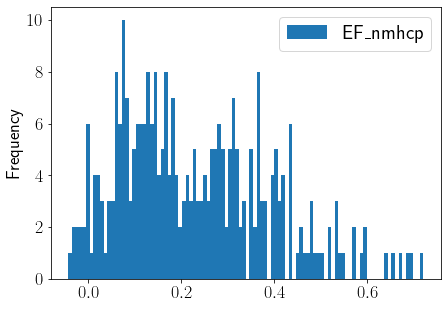

In [18]:
fig, ax =  plt.subplots()
for target_case in ['EF_nmhcp']:
    ax = BS[target_case].plot.hist(ax=ax, label = target_case, bins=100)
ax.legend()

chech that the chemistry resetting is correct!

In [19]:
ground_states

{('Fe_pv1', 'bcc', 'FM'): -8.255227964543023,
 ('Fe_pv2', 'hcp', 'NM'): -8.18407186323532,
 ('Fe_pv4', 'fcc', 'NM'): -8.105011456799609,
 ('Mo_sv1', 'bcc', 'FM'): -10.932754996062988,
 ('Mo_sv1', 'bcc', 'NM'): -10.932821158319513}

In [20]:
ground_state_samples = pd.Series(ground_states).index.map(lambda t: '.'.join(t))

In [21]:
ground_state_samples

Index(['Fe_pv1.bcc.FM', 'Fe_pv2.hcp.NM', 'Fe_pv4.fcc.NM', 'Mo_sv1.bcc.FM',
       'Mo_sv1.bcc.NM'],
      dtype='object')

In [22]:
BS.query('index.str.contains("fcc|bcc|hcp") and nelem==1')[['V0', 'E0', 'B0',target_case]]

,V0,E0,B0,EF_nmhcp
Fe_pv1.bcc.FM,11.356868,-8.255228,210.632901,0.000000
Fe_pv1.bcc.NM,10.481600,-7.790659,269.455898,0.393413
Fe_pv2.hcp.FM,12.029139,-8.065627,157.755333,0.189601
Fe_pv2.hcp.NM,10.193528,-8.184072,287.828951,0.000000
Fe_pv4.fcc-cubic.NM,10.247629,-8.105011,286.467141,0.079060
Mo_sv2.hcp.NM,16.145087,-10.497818,238.430509,0.435003
Mo_sv4.fcc-cubic.FM,16.053362,-10.513988,239.434172,0.418767
Mo_sv4.fcc-cubic.NM,16.058166,-10.513010,240.008475,0.419811
Fe_pv1.fcc.FM,12.021393,-8.107128,167.384487,0.148100
Mo_sv1.bcc.FM,15.825081,-10.932755,251.877901,0.000000


In [23]:
BS.to_pickle("Fe-Mo/FurtherCuratedParsedBriefSummary.pkl")

# guess structures: Define atomic volumes 

In [24]:
atom_volume_keys = {}
with  MPRester("XMK2lneoOyVOQDnhEnVmyX3h4dyJuSyo") as mpr:
    for atom, key in MP_keys.items():
        result =mpr.summary.search(material_ids=[key])[0]
        total_vol = result.volume
        nsites = result.nsites
        atom_volume_keys[atom] = total_vol/nsites

Retrieving SummaryDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

Retrieving SummaryDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

In [25]:
atom_volume_keys

{'Fe': 11.734084234678496, 'Mo': 15.89162790660502}

In [26]:
Features = Featurizer(BS)

# Sort Poscar files

In [27]:
cases

['POSCAR.initial', 'POSCAR.relaxed-all']

In [28]:
for searchs, subcase in zip(cases, subcases):
#    searchs = 'POSCAR.initial'
    files = get_file_paths(dataset, searchs, csvfile=f'ListOfFiles_{searchs}.csv')

    atomsobjectslocation = os.path.join(dataset,'Atomsobjects')
    sublatticesortersfile = os.path.join(atomsobjectslocation, f'SORTERS_{searchs}.pkl')
    sublatticetagfile = os.path.join(atomsobjectslocation, f'SUBLATICETAGS_{searchs}.pkl')

    if True: # not os.path.exists(sublatticesortersfile): # need_to_update(sublatticesortersfile) or need_to_update(sublatticetagfile):
        SORTERS, SUBLATICETAGS = get_all_sorters_and_tags(dataset, files)
        SORTERS.to_pickle(sublatticesortersfile)
        SUBLATICETAGS.to_pickle(sublatticetagfile)
    else:
        SORTERS = pd.read_pickle(sublatticesortersfile)
        SUBLATICETAGS = pd.read_pickle(sublatticetagfile)

  0%|          | 0/766 [00:00<?, ?it/s]

  0%|          | 0/739 [00:00<?, ?it/s]

# Now I have to pick the atoms objects

In [29]:
#for thiscase, (thisrescale, thissubcase) in product(case, zip(rescale_by_atoms, subcase)):
#database = f'{dataset}/**/{case}'

In [30]:
Atoms_Objects = {}

In [31]:
subcases

['rescaled', 'noscaled']

In [32]:
for searchs, subcase in zip(cases, subcases):
    AtomsFile = os.path.join(atomsobjectslocation,f'{dataset}-{searchs}-{subcase}-AtomsObjects.pkl')
    if subcase == 'rescaled':
        booleanflag = True
    else:
        booleanflag = False
    if False : #not need_to_update(AtomsFile):  #os.path.exists(AtomsFile) and not Force:
        Atoms_Objects[searchs] = pd.read_pickle(AtomsFile)
    else:
        Atoms_Objects[searchs], CantMake_Atoms_Object = Features.get_atoms_object(
            database=dataset,
            rescale_by_atoms=booleanflag,
            reset_chemistry=True,
            file_filter = searchs, #'initial$',
            element_volumes=atom_volume_keys
        )
        Atoms_Objects[searchs].to_pickle(AtomsFile)
        Atoms_Objects[searchs].dropna(inplace=True)
    pymatgenfile = AtomsFile.replace('AtomsObjects','PymatgenStructures')
    Pymatgen_Structures = Atoms_Objects[searchs].copy()
    if False: # not need_to_update(pymatgenfile):
        Pymatgen_Structures = pd.read_pickle(pymatgenfile)
    else:
        Pymatgen_Structures = Atoms_Objects[searchs]['atoms'].apply(AseAtomsAdaptor.get_structure)
        Pymatgen_Structures['file'] = Atoms_Objects[searchs]['file']
        Pymatgen_Structures.to_pickle(pymatgenfile)

    accomodatewrap = Atoms_Objects[searchs].atoms.map(lambda a: a.wrap(pretty_translation=True))
    allindex = Atoms_Objects[searchs].index.intersection(BS.index)
    Atoms_Objects[searchs] = Atoms_Objects[searchs].loc[allindex]
    Atoms_Objects[searchs].to_pickle(AtomsFile)

  0%|          | 0/292 [00:00<?, ?it/s]

  0%|          | 0/292 [00:00<?, ?it/s]

In [33]:
for case, AtomsObject in Atoms_Objects.items():
    difference = BS.index.difference(AtomsObject.index)
    print(case, difference)

POSCAR.initial Index([], dtype='object')
POSCAR.relaxed-all Index([], dtype='object')


#  visualization of some structures

In [34]:
plt.rc('axes.spines', bottom=False, top=False, right=False, left=False)

In [35]:
from ase.visualize.plot import plot_atoms

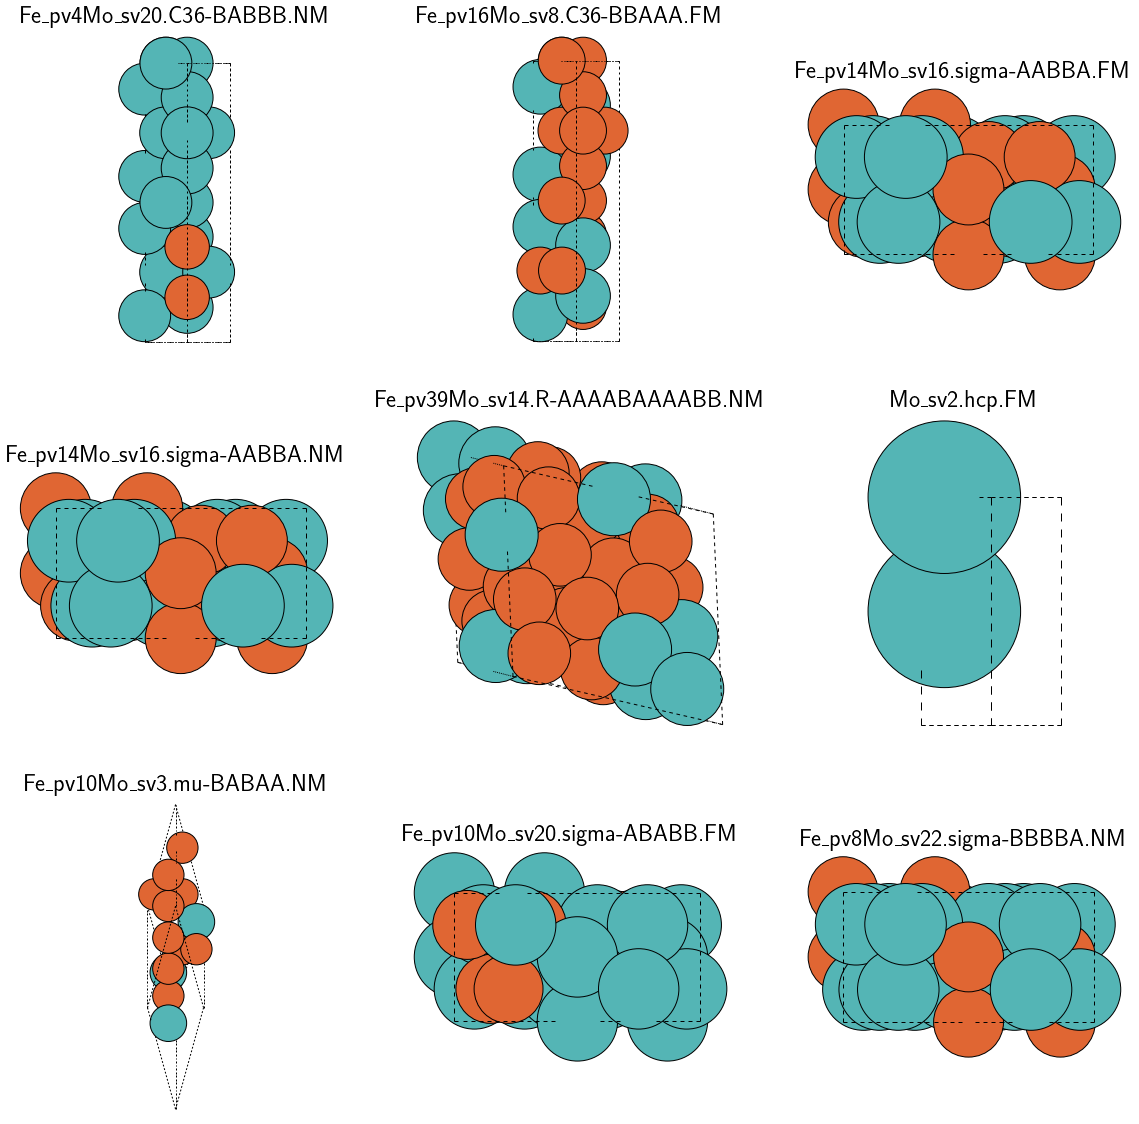

In [36]:
atoms_samples = Atoms_Objects['POSCAR.initial'].atoms.sample(n=9)
fig, ax = plt.subplots(3,3, figsize = (20,20))
ax = ax.flatten()
for thisax, (thisname, thisatoms) in  zip(ax, atoms_samples.iteritems()):
    plot_atoms(thisatoms, ax=thisax, rotation = '90x')
#    [spine.set_visible(False) for spine in thisax.spines.values()]
    thisax.set_xticks([])
    thisax.set_yticks([])
    thisax.set_title(thisname)

In [37]:
somesigmas = Atoms_Objects['POSCAR.initial'].atoms[Atoms_Objects['POSCAR.initial'].index.str.contains('sigma')].sample(n=9)

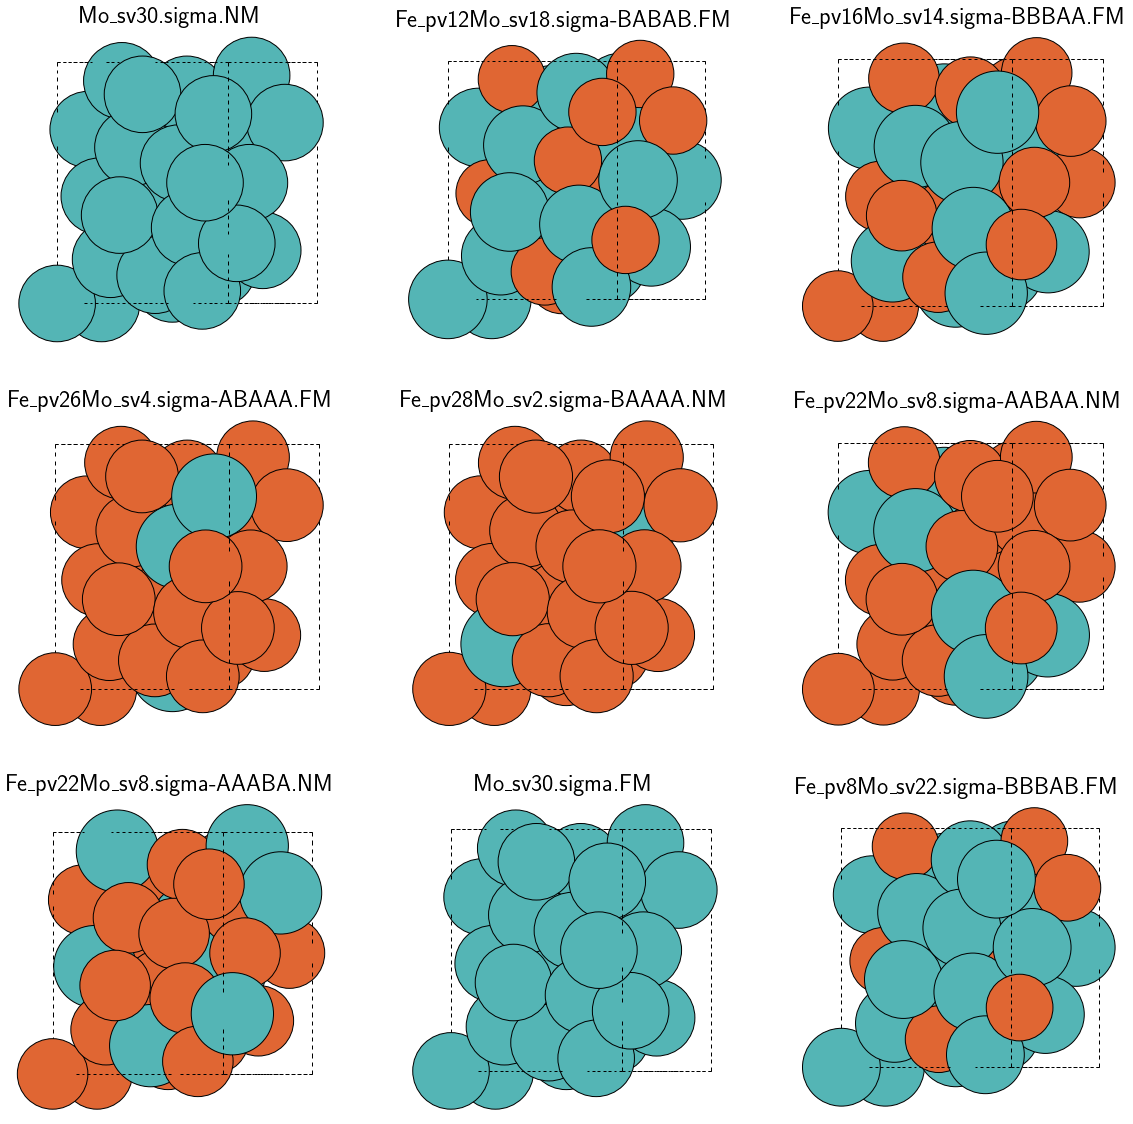

In [38]:
atoms_samples = Atoms_Objects['POSCAR.initial'].atoms.sample(n=9)
fig, ax = plt.subplots(3,3, figsize = (20,20))
ax = ax.flatten()
for thisax, (thisname, thisatoms) in  zip(ax, somesigmas.iteritems()):
    plot_atoms(thisatoms, ax=thisax, rotation='90y, 90x, 45y')
    [spine.set_visible(False) for spine in thisax.spines.values()]
    thisax.set_xticks([])
    thisax.set_yticks([])
    thisax.set_title(thisname)

 For the actual visualization of the structures, we should choose one example for each structure and then draw in Vesta or Ovito for good quality figures, including coordination polyhedra etc.

# Curate Dataset to available structures 

There are still some R structures not available in data but present in briefsummaries

In [39]:
Problems = BS.index.difference(Atoms_Objects['POSCAR.initial'].index)

In [40]:
BS.loc[Problems]

,,V,E0,B,fit,xc,encut,deltak,ncrash,nelem,...,num_atom_A,num_atom_B,num_atoms,Fe_pv,Mo_sv,Mag,Phase,EF_fmbcc,EF_nmhcp,EF_nmfcc


In [41]:
BS.dropna().describe()

,E0,nelem,B0,V0,num_atom_A,num_atom_B,num_atoms,Fe_pv,Mo_sv,EF_fmbcc,EF_nmhcp,EF_nmfcc
count,292.000000,292.000000,292.000000,292.000000,292.00000,292.000000,292.000000,292.000000,292.000000,292.000000,292.000000,292.000000
mean,-9.347206,1.845890,235.138358,13.582107,12.89726,10.291096,23.188356,0.498634,0.501366,0.250462,0.229052,0.205263
std,0.746336,0.361674,31.685307,1.654945,10.85723,9.537817,13.755429,0.292605,0.292605,0.161952,0.162156,0.166363
min,-10.932821,1.000000,141.243922,10.193528,1.00000,0.000000,1.000000,0.000000,0.000000,-0.015446,-0.042841,-0.085488
25%,-9.955671,2.000000,217.823336,12.275667,4.00000,2.750000,13.000000,0.262500,0.266667,0.124923,0.102939,0.072821
50%,-9.332258,2.000000,240.028922,13.425116,10.00000,8.500000,24.000000,0.500000,0.500000,0.228259,0.196050,0.176500
75%,-8.825165,2.000000,260.406947,14.978348,18.00000,16.000000,30.000000,0.733333,0.737500,0.364194,0.336165,0.309251
max,-7.780036,2.000000,287.828951,16.550514,53.00000,52.000000,53.000000,1.000000,1.000000,0.720532,0.720492,0.720492


In [42]:
GoodBS = BS.loc[Atoms_Objects['POSCAR.initial'].index]

In [43]:
GoodBS#.dropna()

,,V,E0,B,fit,xc,encut,deltak,ncrash,nelem,...,num_atom_A,num_atom_B,num_atoms,Fe_pv,Mo_sv,Mag,Phase,EF_fmbcc,EF_nmhcp,EF_nmfcc
Fe_pv4Mo_sv20.C36-ABBBB.FM,bulk C36-ABBBB.FM,16.270923 A,-10.007837,204.470374 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,4,20,24,0.166667,0.833333,FM,C36,0.478663,0.478663,0.478663
Fe_pv15Mo_sv38.R-AAAABBBBBBB.NM,bulk R-AAAABBBBBBB,14.436090 A,-10.020954,255.953497 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,15,38,53,0.283019,0.716981,NM,R,0.154058,0.133919,0.111544
Fe_pv2Mo_sv11.mu-BBABB.FM,bulk mu-BBABB.FM,16.007021 A,-10.117556,215.396114 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,2,11,13,0.153846,0.846154,FM,mu,0.403272,0.403272,0.403272
Fe_pv8Mo_sv22.sigma-BBBAB.NM,bulk sigma-BBBAB,14.426681 A,-10.141531,260.386848 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,8,22,30,0.266667,0.733333,NM,sigma,0.077265,0.058290,0.037208
Fe_pv2Mo_sv11.mu-BBBBA.NM,bulk mu-BBBBA,15.656633 A,-10.146330,235.078776 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,2,11,13,0.153846,0.846154,NM,mu,0.374554,0.363607,0.351444
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Fe_pv6.C15.FM,bulk C15.FM,12.092153 A,-8.111059,148.116428 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.021,0,1,...,6,0,6,1.000000,0.000000,FM,C15,0.144169,0.144169,0.144169
Mo_sv1.bcc.NM,bulk bcc,15.828881 A,-10.932821,259.504388 GPa,murnaghan volume_relaxed,PBE-PAW,400,0.016,0,1,...,1,0,1,0.000000,1.000000,NM,bcc,0.000000,0.000000,0.000000
Mo_sv8.A15.NM,bulk A15,16.079860 A,-10.837515,253.234487 GPa,murnaghan volume_relaxed,PBE-PAW,400,0.016,0,1,...,8,0,8,0.000000,1.000000,NM,A15,0.095306,0.095306,0.095306
Mo_sv1.fcc.NM,bulk fcc,16.059116 A,-10.511038,239.489255 GPa,murnaghan volume_relaxed,PBE-PAW,400,0.012,0,1,...,1,0,1,0.000000,1.000000,NM,fcc,0.421784,0.421784,0.421784


In [44]:
FullyCuratedBSFile = os.path.join(dataset,'FullyCuratedParsedBriefSummary.pkl')

In [45]:
GoodBS.to_pickle(FullyCuratedBSFile)

#  Final Distributions of targets

In [46]:
plt.rc('axes.spines', bottom=True, top=True, right=True, left=True)

<AxesSubplot:xlabel='B0', ylabel='Count'>

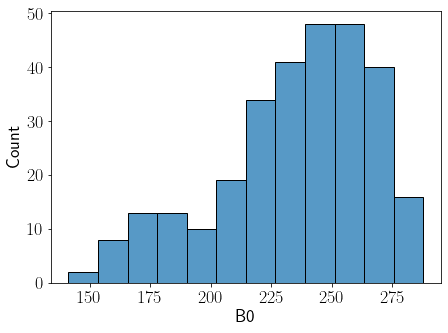

In [47]:
sns.histplot(BS['B0'])

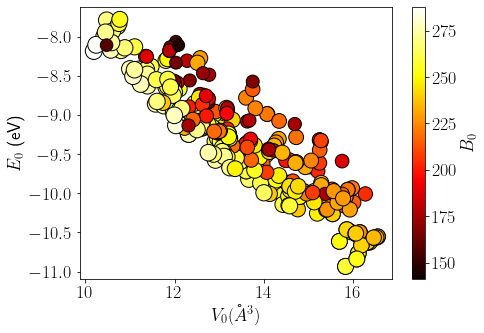

In [48]:
#fig, ax = plt.subplots()
plt.scatter(BS.V0, BS.E0, c=BS.B0, marker = 'o' , s = BS.B0, cmap='hot', edgecolor='k')
cbar = plt.colorbar()
plt.ylabel(r'$E_0$ (eV)')
plt.xlabel(r'$V_0 (\AA^3)$')
cbar.set_label(r'$B_0$')
#outlier_left =BS[(BS['E0']<-10) & (BS['V0']<11)].index
#plt.annotate(outlier_left[0],*BS.loc[outlier_left][['V0', 'E0']].values, fontsize=16 )

# Atomic volumes vs dft

In [49]:
BS.query('num_atoms == 1').groupby('E0').min('E0')#['V0']#reset_index()

,nelem,B0,V0,num_atom_A,num_atom_B,num_atoms,Fe_pv,Mo_sv,EF_fmbcc,EF_nmhcp,EF_nmfcc
E0,,,,,,,,,,,
-10.932821,1,258.072533,15.828552,1,0,1,0.0,1.0,0.000000,0.000000,0.000000
-10.932755,1,251.877901,15.825081,1,0,1,0.0,1.0,0.000000,0.000000,0.000000
-10.511038,1,239.434813,16.058793,1,0,1,0.0,1.0,0.421784,0.421784,0.421784
-8.255228,1,210.632901,11.356868,1,0,1,1.0,0.0,0.000000,0.000000,0.000000
-8.107128,1,167.384487,12.021393,1,0,1,1.0,0.0,0.148100,0.148100,0.148100
-7.790659,1,269.455898,10.481600,1,0,1,1.0,0.0,0.464569,0.393413,0.314353


In [50]:
Fe_unary = BS.query('num_atoms == 1 and Fe_pv == 1')

In [51]:
V_GS_Fe = Fe_unary[Fe_unary.E0 == Fe_unary.E0.min()].V0

In [52]:
V_GS_Fe

Fe_pv1.bcc.FM    11.356868
Name: V0, dtype: float64

In [53]:
Mo_unary = BS.query('num_atoms == 1 and Mo_sv == 1')

In [54]:
V_GS_Mo = Mo_unary[Mo_unary.E0 == Mo_unary.E0.min()].V0

In [55]:
V_GS_Mo

Mo_sv1.bcc.NM    15.828552
Name: V0, dtype: float64

In [56]:
norm = plt.Normalize(BS['Fe_pv'].min(), BS['Fe_pv'].max())
sm = plt.cm.ScalarMappable(norm=norm, cmap='rainbow')
sm.set_array([])

NameError: name 'handles' is not defined

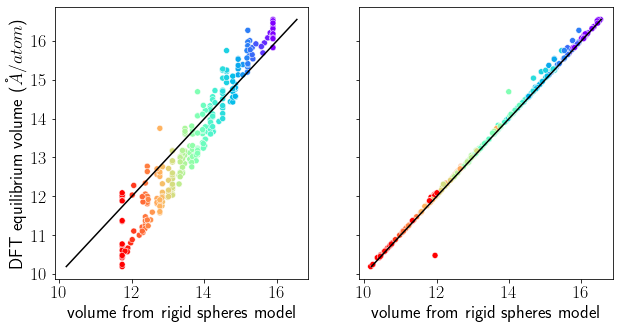

In [57]:
fig, axs = plt.subplots(1, len(Atoms_Objects), figsize = (10,5), sharey=True)
for (case, atoms_df), ax in zip(Atoms_Objects.items(), axs):
    volumes = atoms_df['atoms'].map(lambda a: a.get_volume()/a.get_global_number_of_atoms())
    sns.scatterplot(volumes, BS['V0'], hue=BS['Fe_pv'], ax=ax, palette = 'rainbow', label='data', legend='brief', markers=BS.Phase)
    ax = sns.lineplot(BS['V0'], BS['V0'],ax = ax, color='k', label='x=y', legend='brief')#, hue=BS['Fe_pv'], palette='rainbow')
    ax.set_ylabel(r'DFT equilibrium volume ($ \AA /atom $)')
    ax.set_xlabel('volume from rigid spheres model')
    ax.legend().remove()
#ax.legend(['data', 'x=y'])
#    handles = [
#        plt.Line2D([0],[0], marker='o', linestyle='', c='k'),
#        plt.Line2D([0],[0],linestyle='-', c='k')
#    ]
labels=[
    'data',
    'DFT x=y'
]
ax.legend(handles, labels)
cbarax = fig.add_axes([0.95, 0.15, 0.02, 0.7])
cbar = ax.figure.colorbar(sm, cax=cbarax)
cbar.set_label('Fe content')
plt.savefig(f'{dataset}/graphs/{dataset}-dftV_vs_gressV.pdf')